In [3]:
import os
os.chdir('/home/mech/pinn-infinite-well')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
%matplotlib inline

df = pd.read_csv('outputs/summary/all_runs_noise.csv')
print(f'Total de corridas cargadas: {len(df)}')
df.groupby(['formulation','experiment'])['seed'].nunique()


def sigma_from_experiment(exp_name):
    tag = exp_name.split('_')[1][1:].replace('p', '.')
    return float(tag)

def plot_collapse_rate(df, arch='A1'):
    summary = (df[df['experiment'].str.startswith(arch)]
               .groupby(['formulation','experiment','n'])
               .agg(collapse_rate=('collapse','mean'))
               .reset_index())
    summary['sigma'] = summary['experiment'].apply(sigma_from_experiment)
    sigmas = sorted(summary['sigma'].unique())
    colors = {'sin_rayleigh': '#E24B4A', 'con_rayleigh': '#378ADD'}

    fig, axes = plt.subplots(1, len(sigmas), figsize=(5.5*len(sigmas), 4.5), sharey=True)
    if len(sigmas) == 1: axes = [axes]
    for ax, sigma in zip(axes, sigmas):
        for form in ['sin_rayleigh', 'con_rayleigh']:
            sub = summary[(summary['formulation']==form) & (summary['sigma']==sigma)].sort_values('n')
            if len(sub) == 0: continue
            ax.plot(sub['n'], sub['collapse_rate'], marker='o', color=colors[form], label=form, markersize=4)
        ax.set_title(f'σ = {sigma}'); ax.set_xlabel('n'); ax.set_ylim(-0.05, 1.05); ax.grid(alpha=0.3)
    axes[0].set_ylabel('Tasa de colapso'); axes[0].legend(fontsize=9)
    plt.tight_layout(); plt.show()

def false_positive_summary(df, integral_thr=1e-3, E_rel_thr=1e-3):
    total_collapse = df[df['integral'] < integral_thr].copy()
    for form in ['sin_rayleigh', 'con_rayleigh']:
        sub = total_collapse[total_collapse['formulation']==form]
        n = len(sub)
        if n == 0:
            print(f'{form}: sin casos'); continue
        falsos = (sub['E_rel'] < E_rel_thr).sum()
        print(f'{form}: n={n} | E_rel mediana={sub["E_rel"].median():.4e} | '
              f'falsos positivos={falsos} ({100*falsos/n:.1f}%)')

def plot_honesty_scatter(df):
    collapsed = df[df['collapse']==True].copy()
    eps = 1e-13
    collapsed['integral_plot'] = collapsed['integral'].clip(lower=eps)
    collapsed['E_rel_plot'] = collapsed['E_rel'].clip(lower=eps)
    colors = {'sin_rayleigh': '#E24B4A', 'con_rayleigh': '#378ADD'}

    fig, ax = plt.subplots(figsize=(8,6))
    for form in ['sin_rayleigh', 'con_rayleigh']:
        sub = collapsed[collapsed['formulation']==form]
        ax.scatter(sub['integral_plot'], sub['E_rel_plot'], s=15, alpha=0.3,
                   color=colors[form], label=f'{form} (n={len(sub)})', edgecolors='none')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('integral (log)'); ax.set_ylabel('E_rel (log)')
    ax.axhline(1e-3, color='gray', linestyle='--', linewidth=1)
    ax.legend(); ax.grid(alpha=0.2, which='both')
    plt.tight_layout(); plt.show()

def case_path(formulation, experiment, seed, n, base='outputs/InfiniteWell/noise/runs'):
    return os.path.join(base, formulation, f'{experiment}_seed{seed}', f'mode_{n}')

def show_mode_image(formulation, experiment, seed, n):
    path = os.path.join(case_path(formulation, experiment, seed, n), 'mode.png')
    display(Image(filename=path))

def load_history(formulation, experiment, seed, n):
    path = os.path.join(case_path(formulation, experiment, seed, n), 'history.npz')
    data = np.load(path)
    return data['epochs_logged'], data['E_hist'], data['int_hist']

def plot_energy_freeze_comparison(case_sin, case_con, shared_E_ylim=None):
    epochs_sin, E_sin, int_sin = load_history(*case_sin)
    epochs_con, E_con, int_con = load_history(*case_con)

    fig, axes = plt.subplots(2, 2, figsize=(12,6))
    (ax_i1, ax_i2), (ax_e1, ax_e2) = axes

    for ax_i, ax_e, epochs, E, integ, title, color in [
        (ax_i1, ax_e1, epochs_sin, E_sin, int_sin, 'Sin Rayleigh', '#E24B4A'),
        (ax_i2, ax_e2, epochs_con, E_con, int_con, 'Con Rayleigh', '#378ADD'),
    ]:
        ax_i.plot(epochs, np.clip(integ, 1e-13, None), color='#639922')
        ax_i.set_yscale('log'); ax_i.set_title(title); ax_i.grid(alpha=0.3)
        ax_e.plot(epochs, E, color=color)
        ax_e.grid(alpha=0.3)
        if shared_E_ylim: ax_e.set_ylim(*shared_E_ylim)

    ax_i1.set_ylabel('integral (log)'); ax_e1.set_ylabel('E'); ax_e1.set_xlabel('época'); ax_e2.set_xlabel('época')
    plt.tight_layout(); plt.show()

print('Funciones cargadas.')

Total de corridas cargadas: 7600
Funciones cargadas.


## 1. Motivación — el problema encontrado

### Contexto

En la formulación original de la PINN para el pozo infinito, la energía se trató como un **parámetro libre entrenable**:

$$E = \text{softplus}(\alpha)$$

La pérdida penaliza el residuo de la ecuación de Schrödinger:

$$\mathcal{L}_{PDE} = \left\| \psi'' + E \cdot \psi \right\|^2$$

### El problema

Nada en esta formulación **ata matemáticamente** el valor de $E$ a la forma específica de $\psi$. Son dos cantidades optimizadas de forma acoplada solo débilmente.

Esto permite que la red converja a un $E$ numéricamente razonable, mientras $\psi$ no corresponde en absoluto a la autofunción física — o colapsa a una función casi nula, violando $\int \psi^2\,dx = 1$.

### Evidencia visual

Caso (n=24, σ=0.1): energía con error relativo 2.5×10⁻⁷ (perfecta), pero integral = 0.0000 — colapso total.

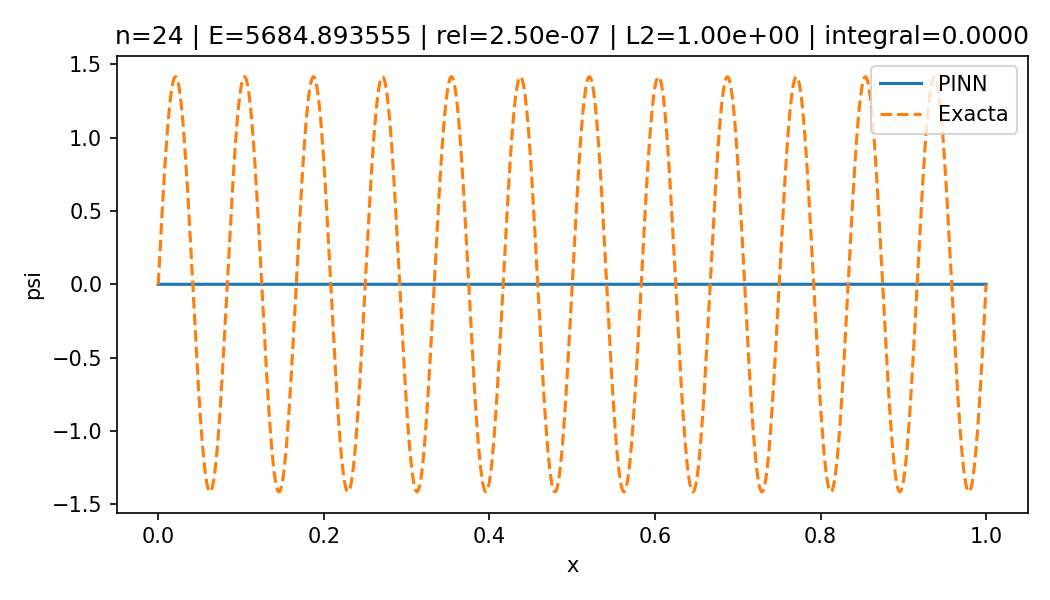

In [4]:
show_mode_image('sin_rayleigh', 'A1_s0p1', 28, 24)

## 2. La corrección — cociente de Rayleigh

En lugar de $E$ como parámetro independiente, se define como funcional de $\psi$:

$$E[\psi] = \frac{\langle \psi | \hat{H} | \psi \rangle}{\langle \psi | \psi \rangle} = \frac{-\int \psi \, \psi'' \, dx}{\int \psi^2 \, dx}$$

### Por qué elimina el problema por construcción

No hay ningún `alpha` que entrenar — $E$ se **calcula** de $\psi$ en cada paso.

Propiedad clave: invariancia de escala:

$$E[c\psi] = E[\psi] \quad \forall c \neq 0$$

Es la formulación variacionalmente correcta (Rayleigh-Ritz): mínimo en el estado fundamental, puntos estacionarios en excitados.

### Consecuencia

$$\mathcal{L}_{PDE} = \left\| \psi'' + E[\psi] \cdot \psi \right\|^2$$

$E$ ya no puede desacoplarse de $\psi$ — el modo de fallo de la Sección 1 se vuelve mucho menos probable (no imposible, ver Sección 5).

## 3. Evidencia — caso limpio (sin ruido)

Con 30 semillas:

| Formulación | Colapso empieza | Colapso total (100%) |
|---|---|---|
| Sin Rayleigh | n ≈ 11-13 | n = 27 |
| Con Rayleigh | n = 27 | no alcanza dentro de n≤30 |

## 4. Evidencia — robustez bajo ruido

### Diseño experimental
- Ruido gaussiano aditivo: $x_{ruidoso} = x + \eta$, $\eta \sim \mathcal{N}(0,\sigma^2)$, truncado [0,1], reordenado
- σ ∈ {0.0, 0.01, 0.05, 0.1} | n = 1-30 | 30 seeds | arch A1
- Total: 7200 entrenamientos (2 formulaciones × 4σ × 30n × 30seeds)

### Resultado
Rayleigh no es inmune al ruido, pero en σ=0.1 (peor caso) la tasa máxima es 50% vs 96-100% en la formulación original.

### Criterio de colapso
$$\text{colapso} = (\text{integral} < 0.2) \text{ AND } (L_2 > 0.5)$$

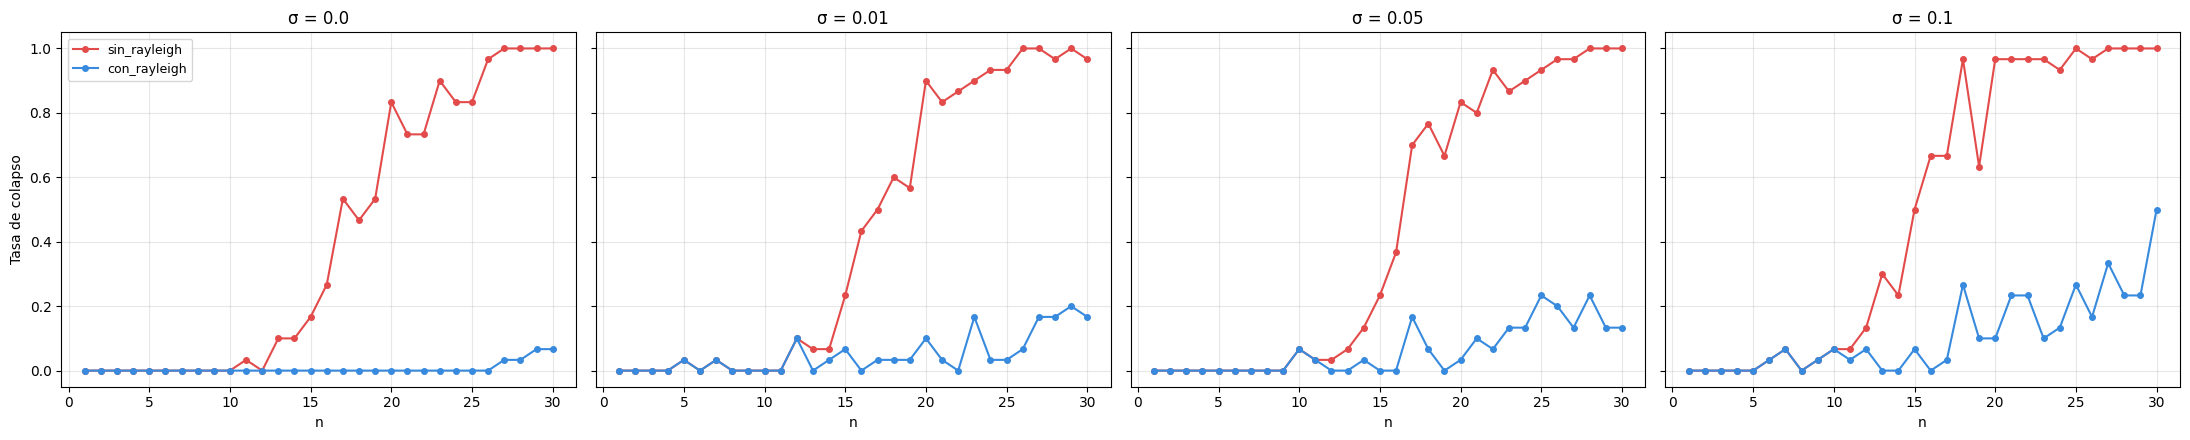

In [5]:
plot_collapse_rate(df, arch='A1')

## 5. El hallazgo más profundo — falsos positivos de energía

### La pregunta
Cuando colapsa, ¿la energía lo refleja, o "miente"?

### Resultado (colapso total, integral < 1e-3)

| Formulación | N° colapsos totales | % energía engañosa |
|---|---|---|
| Sin Rayleigh | 1757 | **98.7%** |
| Con Rayleigh | 173 | **27.7%** |

### El mecanismo

**Sin Rayleigh:** gradiente hacia $\alpha$ ∝ $\psi$. Si $\psi\to0$, gradiente se anula → $\alpha$ se **congela** al azar.

**Con Rayleigh:** invariancia de escala explica el 27.7% restante; colapsos más severos vuelven el cociente numéricamente inestable (denominador→0), degradando E de forma **acoplada** a $\psi$.

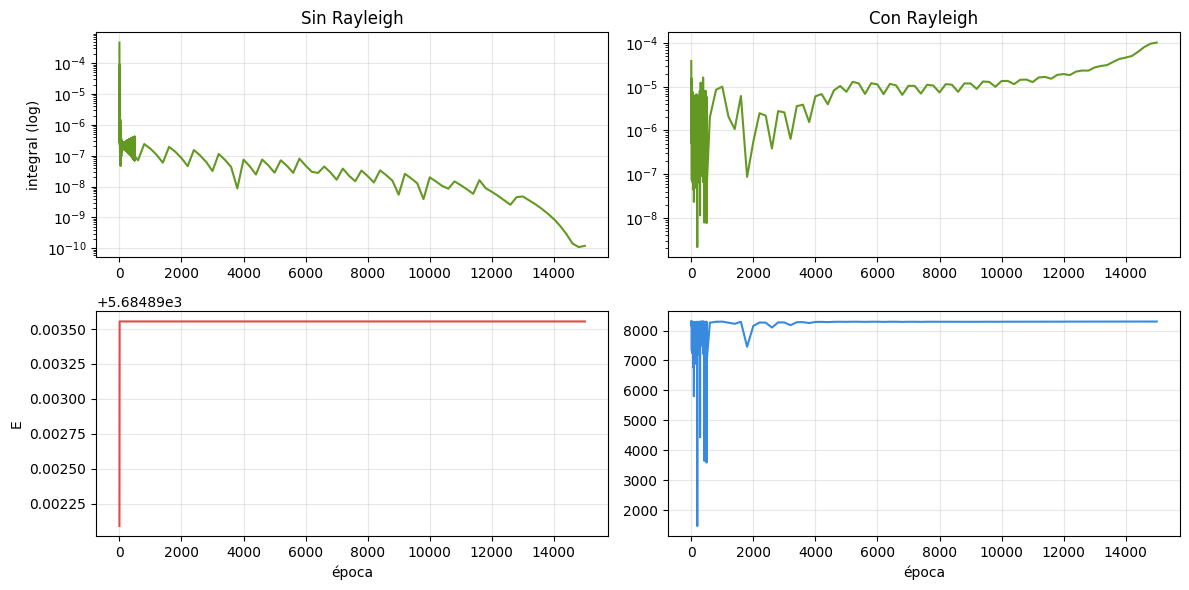

In [6]:
plot_energy_freeze_comparison(
    ('sin_rayleigh', 'A1_s0p1', 28, 24),
    ('con_rayleigh', 'A1_s0p1', 12, 29),
)

### Evidencia estadística completa

- **Rojo (sin Rayleigh):** nube dispersa, sin relación entre colapso y error de energía.
- **Azul (con Rayleigh):** relación lineal (log-log) — más colapso, más error, de forma predecible.

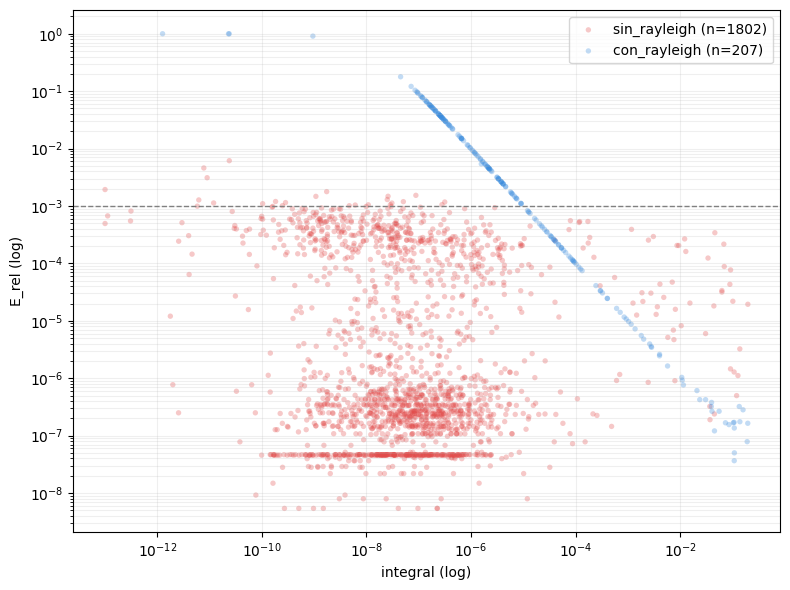

sin_rayleigh: n=1757 | E_rel mediana=4.3854e-07 | falsos positivos=1734 (98.7%)
con_rayleigh: n=173 | E_rel mediana=5.2932e-03 | falsos positivos=48 (27.7%)


In [7]:
plot_honesty_scatter(df)
false_positive_summary(df)

## 6. Por qué esto reemplaza al filtro de Kalman

El anteproyecto planteaba Kalman para "suavizar la trayectoria de optimización". Pero el problema no es de trayectoria ruidosa — es **desacople estructural** entre E y ψ. Un filtro corrige el síntoma; Rayleigh elimina la causa por construcción. No queda claro qué filtraría un mecanismo adicional una vez aplicado.

**Costo de Kalman real:** requeriría UKF/EnKF sobre cientos de parámetros — bloque de estudio comparable a VI-PINN (OE3), el objetivo central de la tesis.

## 7. Propuesta de modificación — OE2

**Actual:**
> "Integrar un esquema de filtrado durante el entrenamiento..."

**Propuesto:**
> "Integrar un esquema de estabilización basado en una formulación variacional del problema (cociente de Rayleigh) durante el entrenamiento..."

**Otros ajustes:** Marco Teórico 10.1.3 (mantener cita Kalman como antecedente), Metodología 12.3, y "barrera de potencial" → "pozo finito".

## 8. Limitaciones y trabajo pendiente

- Rayleigh no es inmune al ruido, solo mucho más robusto
- A2 (256 neuronas): verificación en curso de si corrige el comportamiento anómalo del paper original
- Oscilador armónico: mismo problema detectado, corrección pendiente (ansatz de paridad)
- Pozo finito: 0% de avance, obligatorio
- VI-PINN: prueba de concepto exitosa, mismo fenómeno de colapso reaparece vía kl_weight

## 9. Adelanto — VI-PINN (OE3), prueba de concepto

### Qué es

Extensión bayesiana de la formulación con Rayleigh: los pesos de la red dejan de ser valores fijos y pasan a ser distribuciones $w \sim \mathcal{N}(\mu, \sigma^2)$ (Bayes by Backprop, Blundell et al. 2015), entrenadas minimizando el ELBO:

$$\text{ELBO} = \mathcal{L}_{PDE} + \beta \cdot \text{KL}(q(\theta) \| p(\theta))$$

Esto permite generar **bandas de incertidumbre** sobre $\psi(x)$, no solo una predicción puntual — el objetivo central del título de la tesis.

### Resultado — modo n=1

Ajuste correcto de la media (E_rel ≈ 2×10⁻⁴) con banda de incertidumbre (±2σ) visible, más ancha cerca del pico y cerrada en los bordes (consistente con las condiciones de frontera del ansatz).

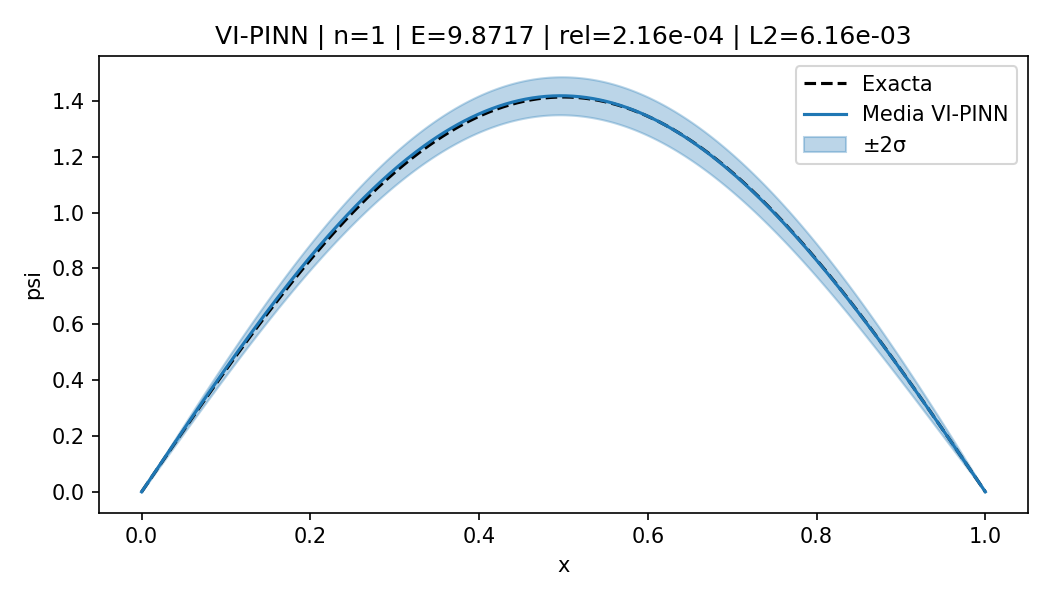

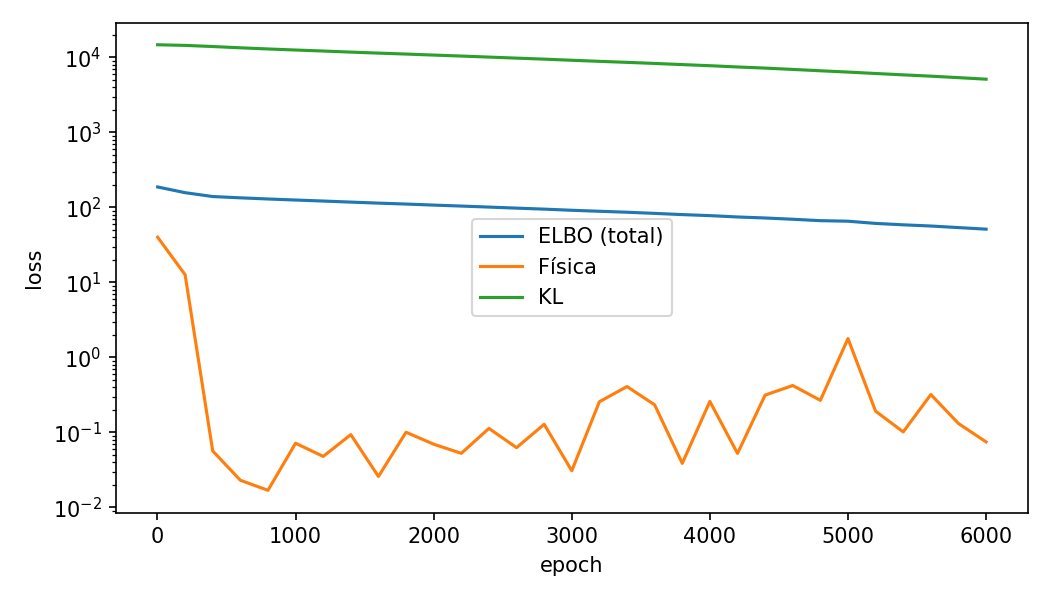

In [13]:
show_vi_images('vi_test_klw01', 0, 1)

### Hallazgo adicional — el mismo fenómeno de colapso reaparece en el régimen bayesiano

Al extender la prueba a un modo más alto (n=9) con el mismo peso de KL (kl_weight=0.01), la red colapsó a una solución casi trivial (ψ≈0 en amplitud), aunque la energía convergió razonablemente (E_rel=5.81e-04) — el mismo patrón de desacople parcial documentado en las Secciones 1 y 5, ahora inducido por un mecanismo distinto: **el término de regularización bayesiana (KL) dominando sobre el ajuste físico**, en vez del parámetro libre de energía.

Por qué la energía sigue pareciendo razonable pese al colapso de amplitud: este VI-PINN está construido *sobre* Rayleigh, así que aplica la misma invariancia de escala discutida en la Sección 5 — una forma nodal aproximadamente correcta con amplitud reducida aún puede dar un cociente de energía cercano al real.

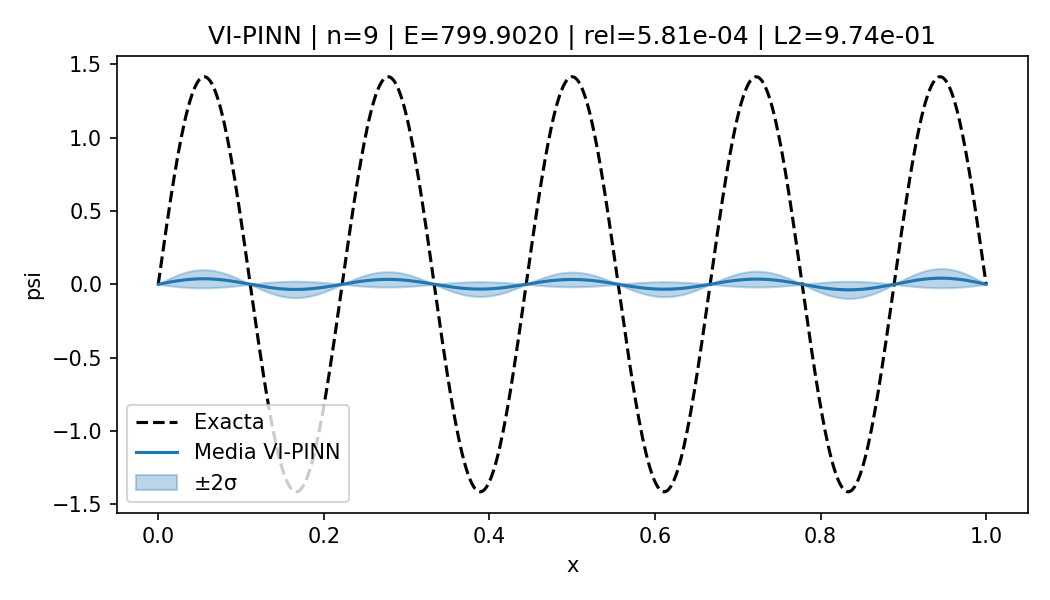

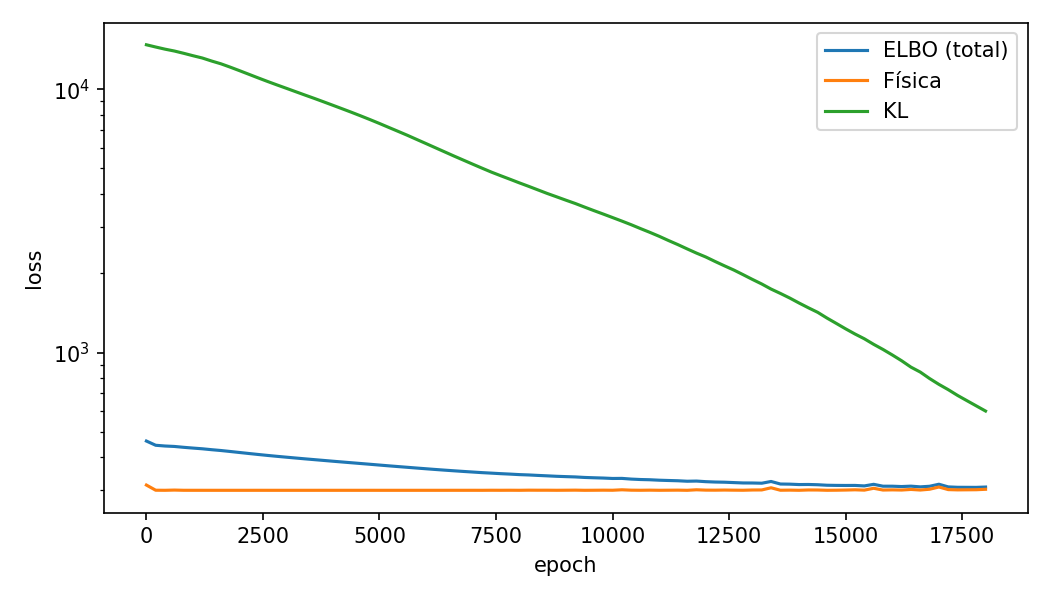

In [14]:
show_vi_images('vi_test_n9', 0, 9)

### Por qué el mismo kl_weight funciona en n=1 pero falla en n=9

El modo fundamental (n=1) requiere pesos moderados para reproducir su forma simple (una sola joroba) — cercanos a lo que el prior ya favorece, sin apenas tensión entre el ajuste físico y la regularización bayesiana.

El modo n=9 exige una señal mucho más articulada (9 oscilaciones completas), lo que requiere pesos más específicos — aquí sí hay tensión real: el optimizador puede "ceder" en la física (dejando que la red produzca una salida casi nula, que sí satisface el prior) en vez de pagar el costo de KL necesario para los pesos correctos.

Esto es consistente con el patrón ya documentado en la formulación determinista: modos bajos son robustos, modos altos se vuelven vulnerables a medida que crece la exigencia estructural del modo.

### Corrección: reducir el peso de KL resuelve el colapso

Bajando `kl_weight` de 0.01 a 0.001, el mismo modo (n=9) converge correctamente — ajuste casi perfecto (E_rel ≈ 3.7×10⁻⁸, L2 ≈ 3.4×10⁻³).

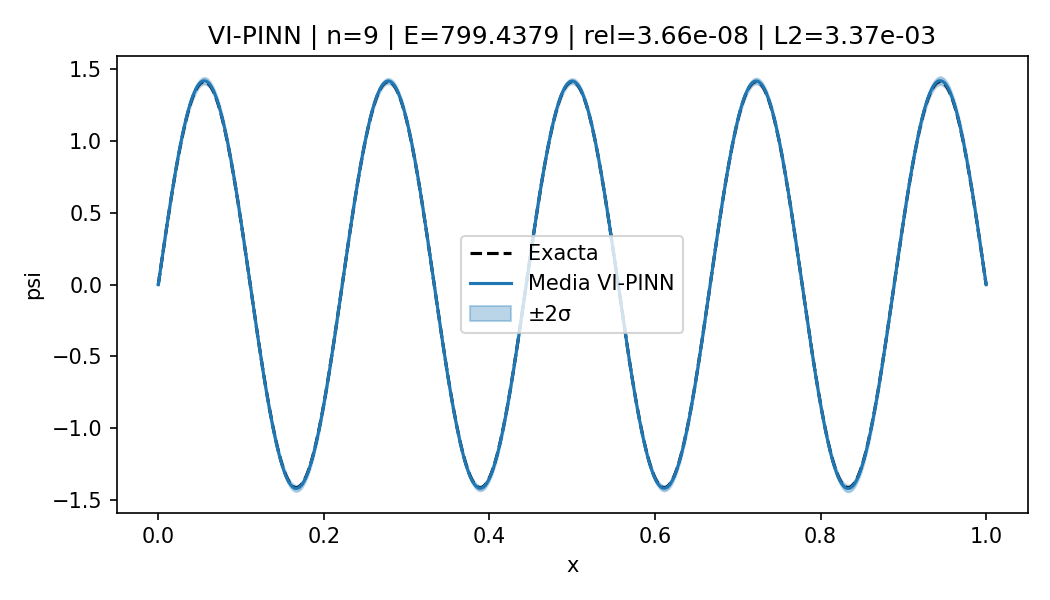

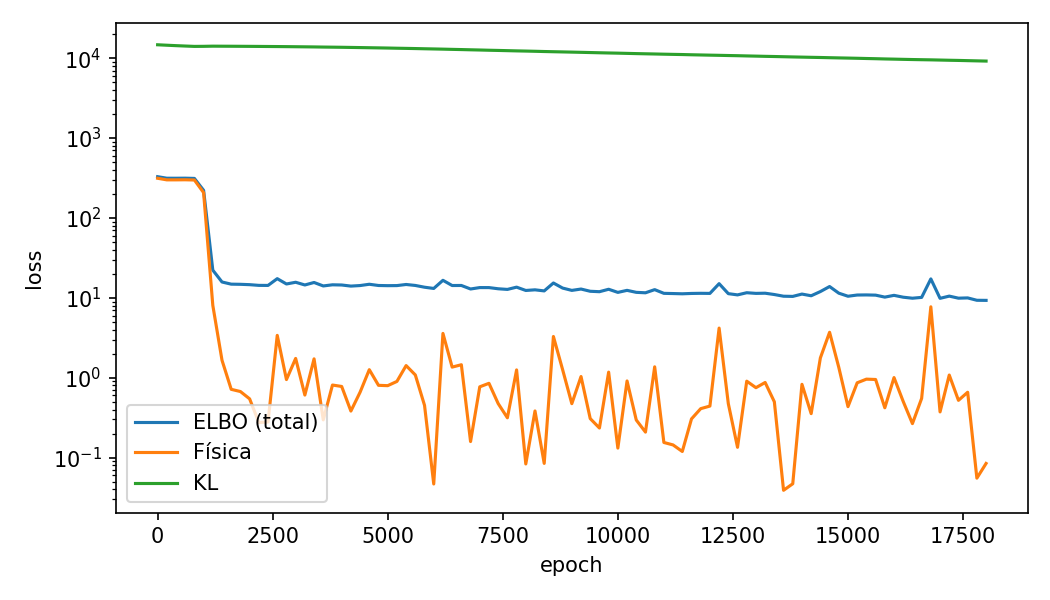

In [15]:
show_vi_images('vi_test_n9_klw001', 0, 9)

### Problema abierto: la corrección elimina el colapso, pero también la incertidumbre

Con kl_weight=0.001, la banda de incertidumbre `±2σ` se vuelve prácticamente invisible — el mismo ajuste que evita el colapso de $\psi$ también reduce drásticamente la incertidumbre reportada, cuestionando si sigue siendo informativa para el propósito central de la tesis (cuantificación de incertidumbre).

**Mecanismo:** con kl_weight bajo, el término de regularización bayesiana apenas penaliza que la varianza de los pesos ($\sigma$ en cada `BayesianLinear`) colapse a valores minúsculos. Nada le exige a la red mantener incertidumbre genuina — reducir $\sigma$ también facilita que la parte física converja mejor, así que el optimizador la "apaga".

### Exploración de un valor intermedio (kl_weight=0.005)

Se probó un valor intermedio buscando un balance entre estabilidad y banda informativa. El resultado (L2=0.980) fue prácticamente idéntico al caso colapsado (kl_weight=0.01, L2=0.974) — **no representa una transición gradual**, sino que se comporta como el caso que falla.

Esto sugiere que la transición entre colapso y convergencia correcta es un **umbral abrupto** (en algún punto entre kl_weight=0.001 y 0.005), consistente con el mismo tipo de comportamiento binario (colapsa/no colapsa) ya documentado en la formulación determinista — el fenómeno de colapso parece ser, en general, un umbral más que una degradación gradual.

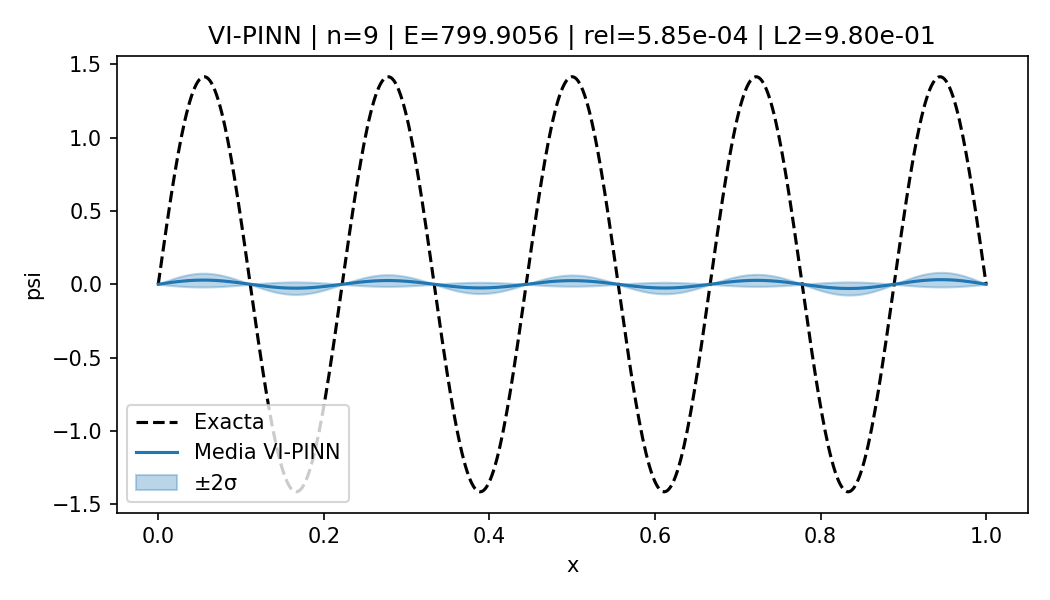

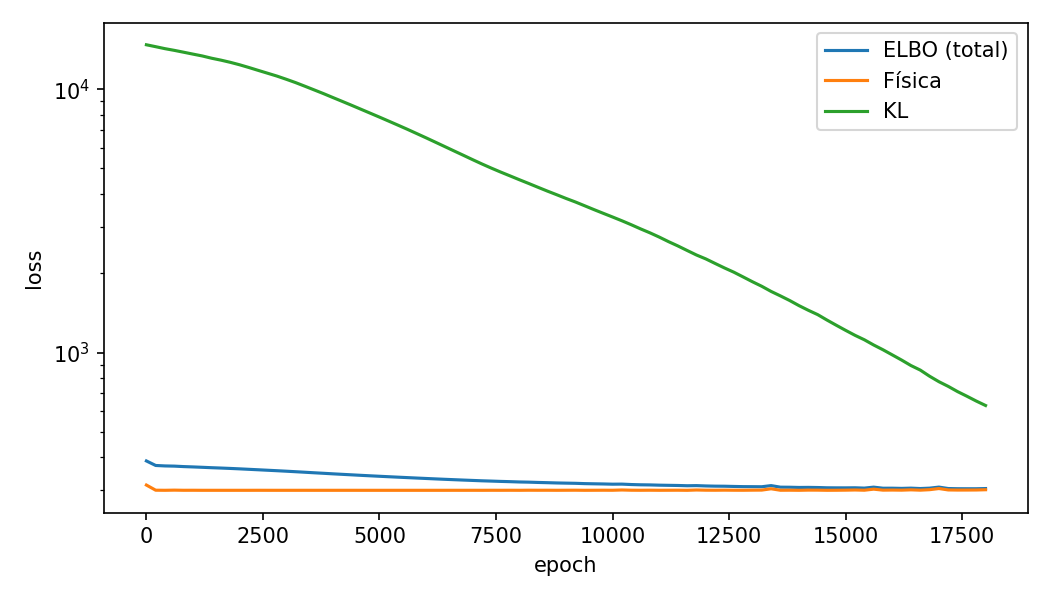

In [17]:
show_vi_images('vi_test_n9_klw005', 0, 9)

### Trabajo pendiente

- Acotar con más precisión la ubicación del umbral de kl_weight (entre 0.001 y 0.005)
- Determinar si ese umbral depende de n, análogo a como `lam` ya escala con n en la formulación determinista
- Explorar alternativas de diseño: *KL annealing* (aumentar kl_weight progresivamente durante el entrenamiento), o ajustar `prior_sigma` en vez de solo `kl_weight`
- Sistematizar el barrido completo de modos una vez definida la estrategia de calibración